# Vision Transformer による BIAS-PROFS データセットの学習

## 1. ライブラリのインポート

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from transformers import (
    ViTImageProcessor,
    ViTForImageClassification,
    Trainer,
    TrainingArguments,
    TrainerCallback,
)
import transformers
import warnings
warnings.filterwarnings("ignore")

# matplotlib日本語文字化け対策
import japanize_matplotlib  # pip install japanize-matplotlib
# もし japanize_matplotlib が使えない場合は以下:
# matplotlib.rcParams['font.family'] = 'IPAexGothic'

# 再現性のためのシード固定
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

E:\ViT-Tutorial\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 設定値

In [2]:
IMAGE_DIR = "../images/bias-profs"
LABEL_CSV = "../labels/bias-profs-labels.csv"
MODEL_NAME = "google/vit-base-patch16-224-in21k"
OUTPUT_DIR = "../models/vit-bias-profs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_CLASSES = 5
CLASS_NAMES = ["A", "B", "C", "D", "E"]
LABEL2ID = {c: i for i, c in enumerate(CLASS_NAMES)}
ID2LABEL = {i: c for i, c in enumerate(CLASS_NAMES)}

# ハイパーパラメータ
LEARNING_RATE = 5e-5
BATCH_SIZE = 16
EPOCHS = 20
WEIGHT_DECAY = 1e-4
N_SPLITS = 5

## 3. ラベルCSVの読み込み

In [3]:
df = pd.read_csv(LABEL_CSV)
print("CSV shape:", df.shape)
print(df.head())

# カラム名を統一(想定: id, class)
df.columns = [c.strip().lower() for c in df.columns]
# id/class カラム自動検出
id_col = [c for c in df.columns if "id" in c][0]
cls_col = [c for c in df.columns if "class" in c][0]

df = df.rename(columns={id_col: "id", cls_col: "label"})
df["label_id"] = df["label"].map(LABEL2ID)

print("\nクラス分布:")
print(df["label"].value_counts().sort_index())

CSV shape: (7716, 2)
   ID Class
0   1     A
1   2     A
2   3     A
3   4     A
4   5     A

クラス分布:
label
A    5302
B     454
C    1929
D      13
E      18
Name: count, dtype: int64


## 4. Dataset 定義

In [4]:
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

class GPCRImageDataset(Dataset):
    def __init__(self, df, image_dir, processor):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{int(row['id'])}.png")
        # グレースケール画像をRGBに変換 (ViTは3チャンネル想定)
        image = Image.open(img_path).convert("RGB")
        encoding = self.processor(images=image, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze(0)
        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(int(row["label_id"]), dtype=torch.long),
        }

## 5. 評価指標の計算関数

In [5]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
    }

## 6. 学習履歴を取得する Callback

In [6]:
class HistoryCallback(TrainerCallback):
    def __init__(self, train_dataset=None):
        self.history = {
            "epoch": [],
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
            "val_precision": [],
            "val_recall": [],
            "val_f1": [],
        }

        self._trainer = None
        self._train_dataset = train_dataset
        self._latest_train_loss = None
        self._in_internal_eval = False

    def set_trainer(self, trainer):
        self._trainer = trainer

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return

        # train lossのみ保持
        if "loss" in logs and "eval_loss" not in logs:
            self._latest_train_loss = logs["loss"]

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if self._in_internal_eval:
            return

        if metrics is None:
            return

        epoch = int(state.epoch)
        train_acc = None

        # ---- train datasetで追加評価 ----
        if self._trainer and self._train_dataset:
            self._in_internal_eval = True
            saved_disable_tqdm = self._trainer.args.disable_tqdm
            saved_verbosity = transformers.logging.get_verbosity()

            try:
                self._trainer.args.disable_tqdm = True
                transformers.logging.set_verbosity_error()

                train_eval = self._trainer.evaluate(
                    eval_dataset=self._train_dataset,
                    metric_key_prefix="train_eval"
                )

                train_acc = train_eval.get(
                    "train_eval_accuracy"
                )
            finally:
                self._trainer.args.disable_tqdm = saved_disable_tqdm
                transformers.logging.set_verbosity(saved_verbosity)
                self._in_internal_eval = False

        # 保存
        self.history["epoch"].append(epoch)
        self.history["train_loss"].append(
            self._latest_train_loss
        )
        self.history["train_acc"].append(
            train_acc
        )

        self.history["val_loss"].append(
            metrics.get("eval_loss")
        )

        self.history["val_acc"].append(
            metrics.get("eval_accuracy")
        )

        self.history["val_precision"].append(
            metrics.get("eval_precision")
        )

        self.history["val_recall"].append(
            metrics.get("eval_recall")
        )

        self.history["val_f1"].append(
            metrics.get("eval_f1_macro")
        )

        train_loss_str = (
            f"{self._latest_train_loss:.4f}"
            if self._latest_train_loss
            else "N/A"
        )

        train_acc_str = (
            f"{train_acc:.4f}"
            if train_acc
            else "N/A"
        )

        print(
            f"[Epoch {epoch}] "
            f"Train Loss:{train_loss_str} | "
            f"Train Acc:{train_acc_str} | "
            f"Val Loss:{metrics['eval_loss']:.4f} | "
            f"Val Acc:{metrics['eval_accuracy']:.4f} | "
            f"Val Precision:{metrics['eval_precision']:.4f} | "
            f"Val Recall:{metrics['eval_recall']:.4f} | "
            f"Val F1:{metrics['eval_f1_macro']:.4f}",
            flush=True
        )

## 7. 学習曲線の描画関数

In [7]:
def plot_learning_curve(history, fold):
    epochs = history["epoch"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Loss ----
    axes[0].plot(epochs, history["train_loss"], "o-", label="Training Loss")
    axes[0].plot(epochs, history["val_loss"], "s-", label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Fold {fold} - 学習曲線 (Loss)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ---- Accuracy ----
    train_acc = [a if a is not None else np.nan for a in history["train_acc"]]
    val_acc = [a if a is not None else np.nan for a in history["val_acc"]]
    axes[1].plot(epochs, train_acc, "o-", label="Training Accuracy")
    axes[1].plot(epochs, val_acc, "s-", label="Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"Fold {fold} - 学習曲線 (Accuracy)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, fold, class_names=CLASS_NAMES):
    """
    左: 件数(カウント)の混同行列
    右: 行方向に正規化した混同行列(.4f)
    """
    cm_count = cm.astype(int)
    cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ---------- 左: カウント(色は行ごとの割合) ----------
    ax = axes[0]
    im0 = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("予測クラス")
    ax.set_ylabel("正解クラス")
    ax.set_title(f"Fold {fold} - 混同行列 (件数)")

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, f"{cm_count[i, j]}",
                    ha="center", va="center", color=color, fontsize=11)
    plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

    # ---------- 右: 正規化 ----------
    ax = axes[1]
    im1 = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("予測クラス")
    ax.set_ylabel("正解クラス")
    ax.set_title(f"Fold {fold} - 混同行列 (正規化)")

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, f"{cm_norm[i, j]:.4f}",
                    ha="center", va="center", color=color, fontsize=10)
    plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

## 8. 5分割交差検証 学習


Fold 1/5 開始


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1123.39it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Eval Loss,Eval Accuracy,Eval Precision,Eval Recall,Eval F1 Macro,Accuracy,Precision,Recall,F1 Macro
1,0.371325,0.193961,0.160036,0.960143,0.570634,0.536223,0.550441,0.952073,0.562416,0.525530,0.541438
2,0.145334,0.151175,0.106359,0.969054,0.552006,0.574190,0.562545,0.957902,0.539464,0.566680,0.552170
3,0.090096,0.116520,0.052781,0.988496,0.789359,0.741265,0.762692,0.969560,0.765806,0.710170,0.734359
4,0.061306,0.119880,0.045502,0.987686,0.969979,0.776711,0.818861,0.971503,0.786539,0.747121,0.764095
5,0.041076,0.164248,0.048986,0.987362,0.993759,0.772379,0.808109,0.965674,0.782321,0.751853,0.765940
6,0.032068,0.118089,0.021599,0.994653,0.967459,0.837244,0.864432,0.972798,0.707939,0.759908,0.726951
7,0.023807,0.108807,0.014600,0.996273,0.997307,0.873327,0.909571,0.975389,0.779832,0.761631,0.769961
8,0.019884,0.113944,0.011954,0.996273,0.931029,0.913489,0.921883,0.977979,0.741147,0.769430,0.752846
9,0.014752,0.107592,0.011275,0.996436,0.997439,0.873878,0.909919,0.979922,0.778363,0.772312,0.775166
10,0.012086,0.145135,0.012563,0.995949,0.998332,0.871217,0.908972,0.974093,0.785476,0.759269,0.771269


[Epoch 1] Train Loss:0.3713 | Train Acc:0.9601 | Val Loss:0.1940 | Val Acc:0.9521 | Val Precision:0.5624 | Val Recall:0.5255 | Val F1:0.5414
[Epoch 2] Train Loss:0.1453 | Train Acc:0.9691 | Val Loss:0.1512 | Val Acc:0.9579 | Val Precision:0.5395 | Val Recall:0.5667 | Val F1:0.5522
[Epoch 3] Train Loss:0.0901 | Train Acc:0.9885 | Val Loss:0.1165 | Val Acc:0.9696 | Val Precision:0.7658 | Val Recall:0.7102 | Val F1:0.7344
[Epoch 4] Train Loss:0.0613 | Train Acc:0.9877 | Val Loss:0.1199 | Val Acc:0.9715 | Val Precision:0.7865 | Val Recall:0.7471 | Val F1:0.7641
[Epoch 5] Train Loss:0.0411 | Train Acc:0.9874 | Val Loss:0.1642 | Val Acc:0.9657 | Val Precision:0.7823 | Val Recall:0.7519 | Val F1:0.7659
[Epoch 6] Train Loss:0.0321 | Train Acc:0.9947 | Val Loss:0.1181 | Val Acc:0.9728 | Val Precision:0.7079 | Val Recall:0.7599 | Val F1:0.7270
[Epoch 7] Train Loss:0.0238 | Train Acc:0.9963 | Val Loss:0.1088 | Val Acc:0.9754 | Val Precision:0.7798 | Val Recall:0.7616 | Val F1:0.7700
[Epoch 8] Tra

Training Loss,Validation Loss,Epoch,Eval Loss,Eval Accuracy,Eval Precision,Eval Recall,Eval F1 Macro
0.008287,No log,20,0.008167,0.996436,0.997439,0.873878,0.909919


[Epoch 20] Train Loss:0.0083 | Train Acc:0.9964 | Val Loss:0.1565 | Val Acc:0.9741 | Val Precision:0.7412 | Val Recall:0.7630 | Val F1:0.7494


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Macro
0.008287,0.156532,20,0.974093,0.741245,0.762956,0.749368



Fold 1 最終評価結果: {'eval_loss': 0.15653227269649506, 'eval_accuracy': 0.9740932642487047, 'eval_precision': 0.7412446261335839, 'eval_recall': 0.7629562143794001, 'eval_f1_macro': 0.7493675607654173}



Classification Report:
              precision    recall  f1-score   support

           A     0.9796    0.9934    0.9864      1061
           B     0.9634    0.8681    0.9133        91
           C     0.9633    0.9532    0.9582       385
           D     0.0000    0.0000    0.0000         3
           E     0.8000    1.0000    0.8889         4

    accuracy                         0.9741      1544
   macro avg     0.7412    0.7630    0.7494      1544
weighted avg     0.9722    0.9741    0.9729      1544



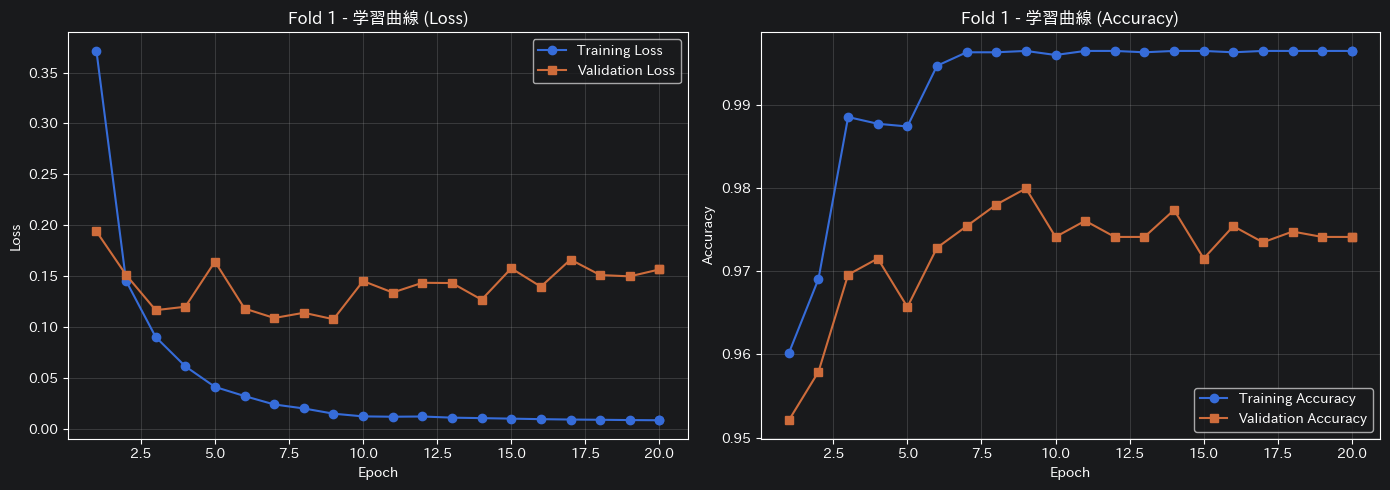

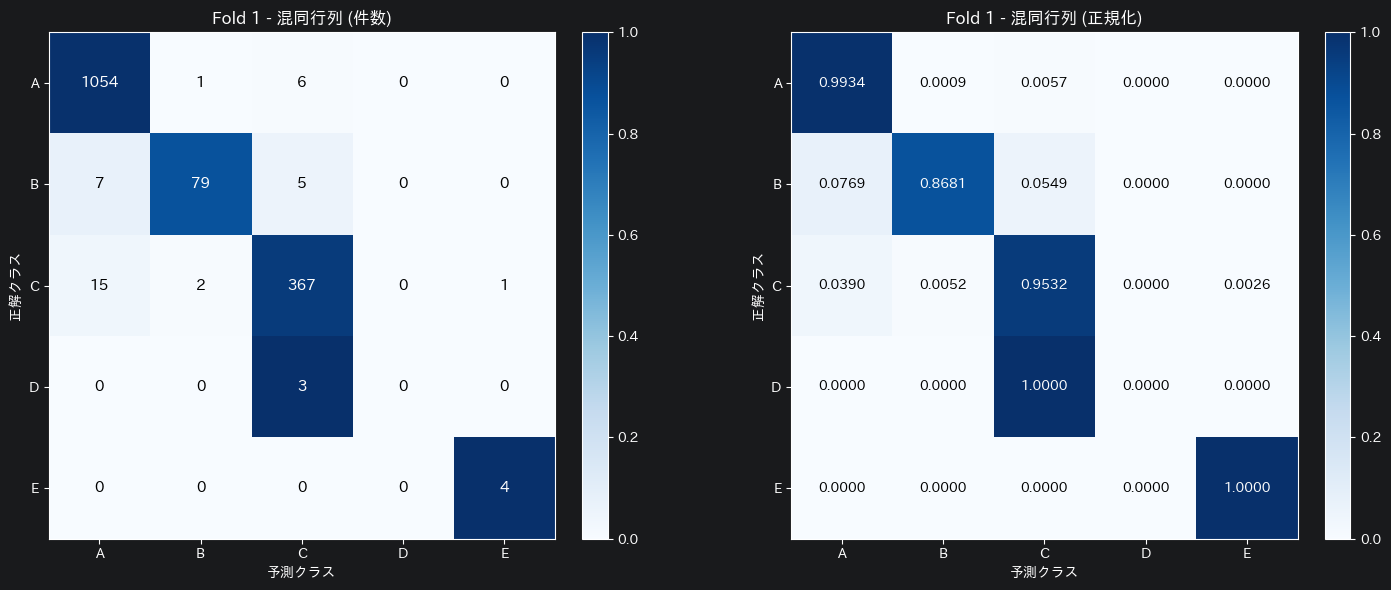


Fold 2/5 開始


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1124.87it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Eval Loss,Eval Accuracy,Eval Precision,Eval Recall,Eval F1 Macro,Accuracy,Precision,Recall,F1 Macro
1,0.366376,0.179007,0.153728,0.963227,0.562396,0.554340,0.558209,0.953338,0.564207,0.537269,0.548798
2,0.147538,0.153443,0.087659,0.977807,0.584037,0.563801,0.573187,0.959819,0.573533,0.528930,0.546829
3,0.093648,0.138523,0.055759,0.986068,0.679673,0.767701,0.706858,0.957874,0.597553,0.674294,0.602978
4,0.063783,0.174444,0.047572,0.988984,0.775768,0.767771,0.771677,0.953986,0.757101,0.664754,0.703290
5,0.047566,0.209792,0.043854,0.990118,0.781266,0.763977,0.772107,0.957226,0.706521,0.648270,0.670426
6,0.037462,0.180105,0.021774,0.994330,0.896536,0.797713,0.820172,0.961763,0.667172,0.675257,0.666430
7,0.027199,0.189485,0.023494,0.994330,0.796322,0.777003,0.786356,0.965003,0.774284,0.672518,0.714036
8,0.025019,0.163029,0.015561,0.994978,0.907037,0.941928,0.920424,0.963059,0.772745,0.813373,0.785698
9,0.021975,0.260846,0.027278,0.991738,0.995675,0.826564,0.872766,0.953986,0.873210,0.709079,0.772436
10,0.019097,0.188729,0.013933,0.995302,0.996858,0.838817,0.879868,0.965003,0.794961,0.747405,0.766801


[Epoch 1] Train Loss:0.3664 | Train Acc:0.9632 | Val Loss:0.1790 | Val Acc:0.9533 | Val Precision:0.5642 | Val Recall:0.5373 | Val F1:0.5488
[Epoch 2] Train Loss:0.1475 | Train Acc:0.9778 | Val Loss:0.1534 | Val Acc:0.9598 | Val Precision:0.5735 | Val Recall:0.5289 | Val F1:0.5468
[Epoch 3] Train Loss:0.0936 | Train Acc:0.9861 | Val Loss:0.1385 | Val Acc:0.9579 | Val Precision:0.5976 | Val Recall:0.6743 | Val F1:0.6030
[Epoch 4] Train Loss:0.0638 | Train Acc:0.9890 | Val Loss:0.1744 | Val Acc:0.9540 | Val Precision:0.7571 | Val Recall:0.6648 | Val F1:0.7033
[Epoch 5] Train Loss:0.0476 | Train Acc:0.9901 | Val Loss:0.2098 | Val Acc:0.9572 | Val Precision:0.7065 | Val Recall:0.6483 | Val F1:0.6704
[Epoch 6] Train Loss:0.0375 | Train Acc:0.9943 | Val Loss:0.1801 | Val Acc:0.9618 | Val Precision:0.6672 | Val Recall:0.6753 | Val F1:0.6664
[Epoch 7] Train Loss:0.0272 | Train Acc:0.9943 | Val Loss:0.1895 | Val Acc:0.9650 | Val Precision:0.7743 | Val Recall:0.6725 | Val F1:0.7140
[Epoch 8] Tra

Training Loss,Validation Loss,Epoch,Eval Loss,Eval Accuracy,Eval Precision,Eval Recall,Eval F1 Macro
0.009257,No log,20,0.009069,0.995626,0.997034,0.852197,0.886876


[Epoch 20] Train Loss:0.0093 | Train Acc:0.9956 | Val Loss:0.2341 | Val Acc:0.9618 | Val Precision:0.8206 | Val Recall:0.8028 | Val F1:0.8017


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Macro
0.009257,0.234050,20,0.961763,0.820563,0.802828,0.801698



Fold 2 最終評価結果: {'eval_loss': 0.23405028879642487, 'eval_accuracy': 0.9617627997407647, 'eval_precision': 0.8205625794206115, 'eval_recall': 0.8028275537627845, 'eval_f1_macro': 0.8016981165686687}



Classification Report:
              precision    recall  f1-score   support

           A     0.9821    0.9811    0.9816      1061
           B     0.9565    0.7333    0.8302        90
           C     0.9142    0.9663    0.9395       386
           D     0.5000    0.3333    0.4000         3
           E     0.7500    1.0000    0.8571         3

    accuracy                         0.9618      1543
   macro avg     0.8206    0.8028    0.8017      1543
weighted avg     0.9622    0.9618    0.9609      1543



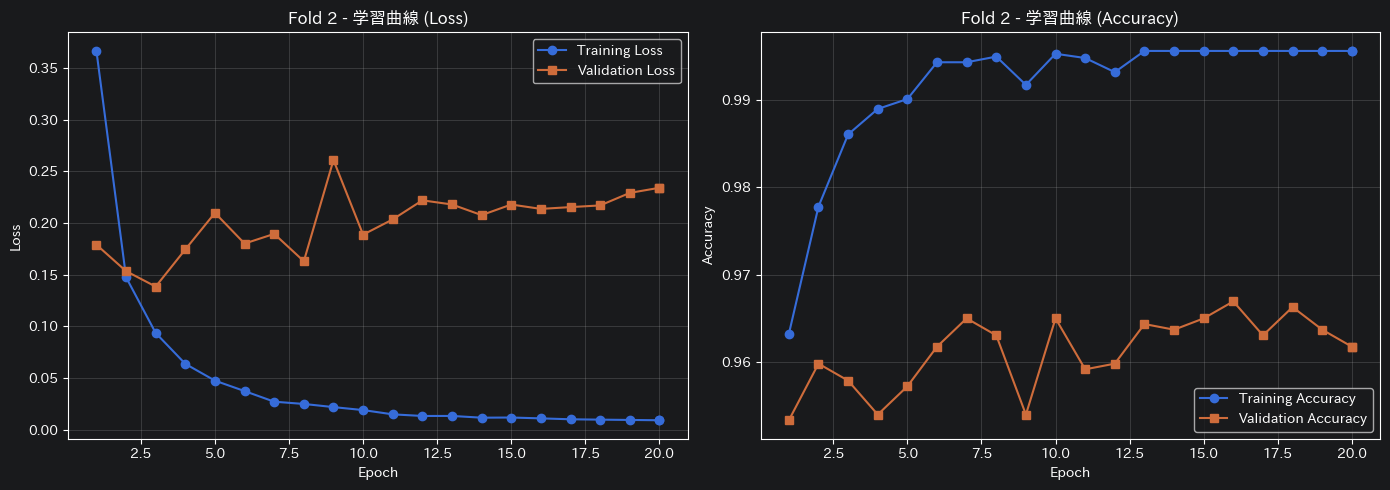

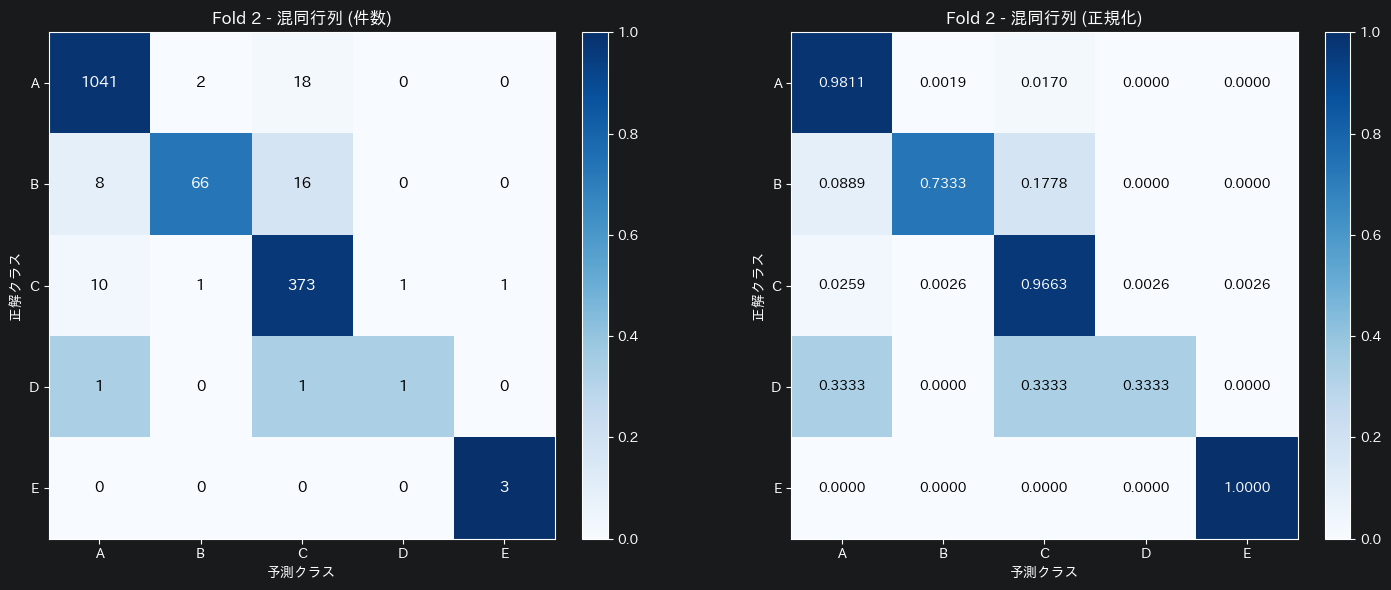


Fold 3/5 開始


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1289.12it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Eval Loss,Eval Accuracy,Eval Precision,Eval Recall,Eval F1 Macro,Accuracy,Precision,Recall,F1 Macro
1,0.360682,0.202089,0.160044,0.964361,0.562083,0.549088,0.554998,0.948153,0.540500,0.547697,0.544021
2,0.162976,0.225012,0.135019,0.963551,0.533215,0.567539,0.547647,0.937135,0.505487,0.558650,0.523610
3,0.103578,0.162103,0.063211,0.983152,0.781142,0.697979,0.729365,0.959819,0.756584,0.635227,0.662391
4,0.071560,0.161333,0.041164,0.989794,0.772393,0.731861,0.750030,0.965651,0.771412,0.638307,0.671516
5,0.043748,0.168181,0.033315,0.991414,0.920481,0.803498,0.779473,0.961115,0.668662,0.700797,0.682342
6,0.033900,0.174244,0.019384,0.994816,0.902396,0.913990,0.907932,0.966948,0.860113,0.778986,0.809039
7,0.023696,0.205152,0.014814,0.996274,0.997385,0.872823,0.909351,0.961763,0.766192,0.699008,0.725889
8,0.022354,0.186631,0.015968,0.995302,0.910446,0.971809,0.933292,0.966299,0.832813,0.771420,0.795402
9,0.016469,0.201407,0.016762,0.995140,0.996487,0.832670,0.861204,0.963707,0.760220,0.712191,0.729132
10,0.018982,0.195438,0.011036,0.996274,0.997903,0.872823,0.909602,0.963059,0.763475,0.701033,0.725526


[Epoch 1] Train Loss:0.3607 | Train Acc:0.9644 | Val Loss:0.2021 | Val Acc:0.9482 | Val Precision:0.5405 | Val Recall:0.5477 | Val F1:0.5440
[Epoch 2] Train Loss:0.1630 | Train Acc:0.9636 | Val Loss:0.2250 | Val Acc:0.9371 | Val Precision:0.5055 | Val Recall:0.5587 | Val F1:0.5236
[Epoch 3] Train Loss:0.1036 | Train Acc:0.9832 | Val Loss:0.1621 | Val Acc:0.9598 | Val Precision:0.7566 | Val Recall:0.6352 | Val F1:0.6624
[Epoch 4] Train Loss:0.0716 | Train Acc:0.9898 | Val Loss:0.1613 | Val Acc:0.9657 | Val Precision:0.7714 | Val Recall:0.6383 | Val F1:0.6715
[Epoch 5] Train Loss:0.0437 | Train Acc:0.9914 | Val Loss:0.1682 | Val Acc:0.9611 | Val Precision:0.6687 | Val Recall:0.7008 | Val F1:0.6823
[Epoch 6] Train Loss:0.0339 | Train Acc:0.9948 | Val Loss:0.1742 | Val Acc:0.9669 | Val Precision:0.8601 | Val Recall:0.7790 | Val F1:0.8090
[Epoch 7] Train Loss:0.0237 | Train Acc:0.9963 | Val Loss:0.2052 | Val Acc:0.9618 | Val Precision:0.7662 | Val Recall:0.6990 | Val F1:0.7259
[Epoch 8] Tra

Training Loss,Validation Loss,Epoch,Eval Loss,Eval Accuracy,Eval Precision,Eval Recall,Eval F1 Macro
0.007523,No log,20,0.007370,0.996436,0.997951,0.872952,0.909690


[Epoch 20] Train Loss:0.0075 | Train Acc:0.9964 | Val Loss:0.2337 | Val Acc:0.9669 | Val Precision:0.7745 | Val Recall:0.7018 | Val F1:0.7314


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Macro
0.007523,0.233661,20,0.966948,0.774472,0.701803,0.731373



Fold 3 最終評価結果: {'eval_loss': 0.23366111516952515, 'eval_accuracy': 0.9669475048606611, 'eval_precision': 0.7744723626455718, 'eval_recall': 0.7018033157900202, 'eval_f1_macro': 0.7313730209155065}



Classification Report:
              precision    recall  f1-score   support

           A     0.9775    0.9821    0.9798      1060
           B     0.9540    0.9121    0.9326        91
           C     0.9409    0.9482    0.9445       386
           D     0.0000    0.0000    0.0000         3
           E     1.0000    0.6667    0.8000         3

    accuracy                         0.9669      1543
   macro avg     0.7745    0.7018    0.7314      1543
weighted avg     0.9651    0.9669    0.9659      1543



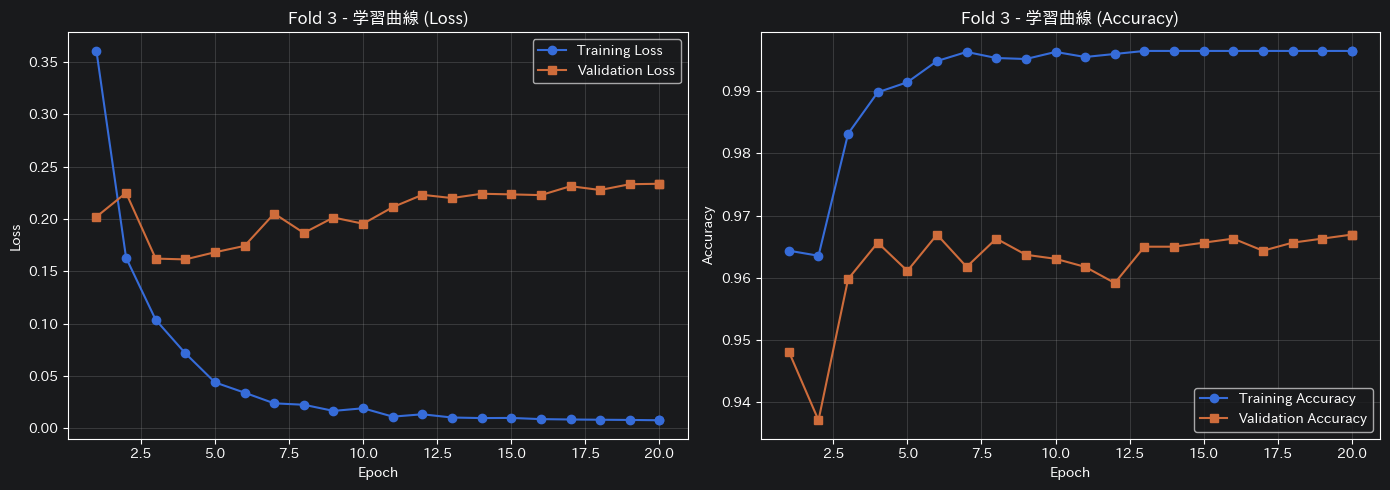

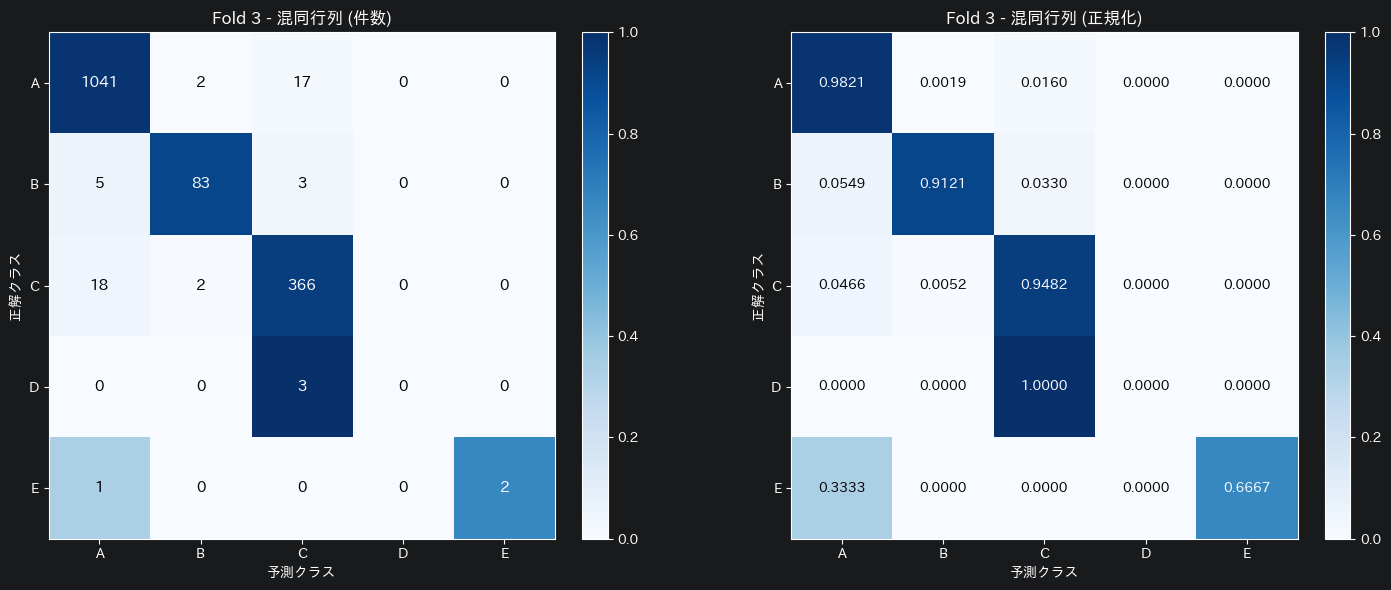


Fold 4/5 開始


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 473.11it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Eval Loss,Eval Accuracy,Eval Precision,Eval Recall,Eval F1 Macro,Accuracy,Precision,Recall,F1 Macro
1,0.374487,0.215722,0.167608,0.955937,0.537495,0.550375,0.543636,0.941024,0.521069,0.543186,0.531446
2,0.153870,0.201691,0.119593,0.970031,0.773735,0.623448,0.658803,0.944264,0.545869,0.541294,0.543354
3,0.090034,0.167203,0.067714,0.982990,0.972597,0.745080,0.794365,0.959819,0.752235,0.753930,0.752978
4,0.061969,0.147318,0.035231,0.991900,0.991678,0.770020,0.819431,0.966948,0.759226,0.764042,0.761600
5,0.042610,0.191525,0.027985,0.992872,0.888214,0.863062,0.875199,0.958522,0.966886,0.838674,0.884517
6,0.024494,0.176542,0.018371,0.995302,0.897994,0.974479,0.924334,0.959819,0.826288,0.850809,0.835120
7,0.025232,0.181864,0.016037,0.995464,0.956449,0.866626,0.895159,0.963059,0.762909,0.754215,0.758238
8,0.018446,0.196093,0.011790,0.996436,0.997791,0.849021,0.881823,0.961115,0.761094,0.747918,0.753401
9,0.015414,0.213885,0.013128,0.995788,0.996839,0.829690,0.856589,0.961763,0.759475,0.752455,0.755202
10,0.013017,0.188814,0.010116,0.995626,0.919971,0.924017,0.921964,0.961763,0.759513,0.752519,0.755868


[Epoch 1] Train Loss:0.3745 | Train Acc:0.9559 | Val Loss:0.2157 | Val Acc:0.9410 | Val Precision:0.5211 | Val Recall:0.5432 | Val F1:0.5314
[Epoch 2] Train Loss:0.1539 | Train Acc:0.9700 | Val Loss:0.2017 | Val Acc:0.9443 | Val Precision:0.5459 | Val Recall:0.5413 | Val F1:0.5434
[Epoch 3] Train Loss:0.0900 | Train Acc:0.9830 | Val Loss:0.1672 | Val Acc:0.9598 | Val Precision:0.7522 | Val Recall:0.7539 | Val F1:0.7530
[Epoch 4] Train Loss:0.0620 | Train Acc:0.9919 | Val Loss:0.1473 | Val Acc:0.9669 | Val Precision:0.7592 | Val Recall:0.7640 | Val F1:0.7616
[Epoch 5] Train Loss:0.0426 | Train Acc:0.9929 | Val Loss:0.1915 | Val Acc:0.9585 | Val Precision:0.9669 | Val Recall:0.8387 | Val F1:0.8845
[Epoch 6] Train Loss:0.0245 | Train Acc:0.9953 | Val Loss:0.1765 | Val Acc:0.9598 | Val Precision:0.8263 | Val Recall:0.8508 | Val F1:0.8351
[Epoch 7] Train Loss:0.0252 | Train Acc:0.9955 | Val Loss:0.1819 | Val Acc:0.9631 | Val Precision:0.7629 | Val Recall:0.7542 | Val F1:0.7582
[Epoch 8] Tra

Training Loss,Validation Loss,Epoch,Eval Loss,Eval Accuracy,Eval Precision,Eval Recall,Eval F1 Macro
0.007873,No log,20,0.007732,0.996436,0.997791,0.849021,0.881823


[Epoch 20] Train Loss:0.0079 | Train Acc:0.9964 | Val Loss:0.2266 | Val Acc:0.9644 | Val Precision:0.7617 | Val Recall:0.7526 | Val F1:0.7568


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Macro
0.007873,0.226607,20,0.964355,0.761663,0.752583,0.756817



Fold 4 最終評価結果: {'eval_loss': 0.226606547832489, 'eval_accuracy': 0.9643551523007129, 'eval_precision': 0.7616629671870465, 'eval_recall': 0.7525827452438069, 'eval_f1_macro': 0.756817133567012}



Classification Report:
              precision    recall  f1-score   support

           A     0.9811    0.9802    0.9807      1060
           B     0.8929    0.8242    0.8571        91
           C     0.9343    0.9585    0.9463       386
           D     0.0000    0.0000    0.0000         2
           E     1.0000    1.0000    1.0000         4

    accuracy                         0.9644      1543
   macro avg     0.7617    0.7526    0.7568      1543
weighted avg     0.9630    0.9644    0.9636      1543



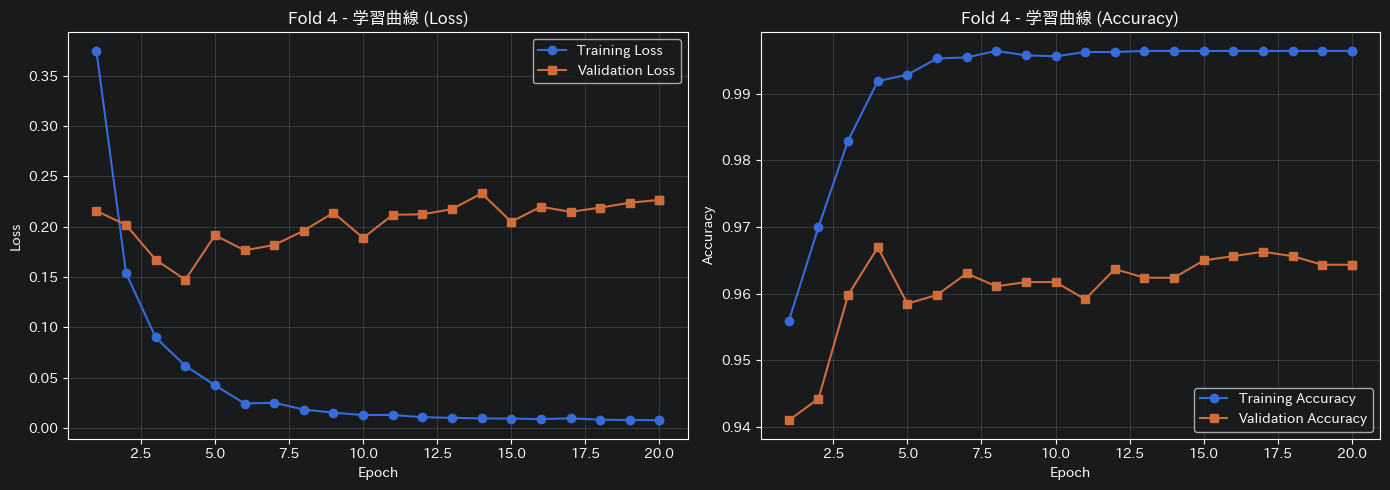

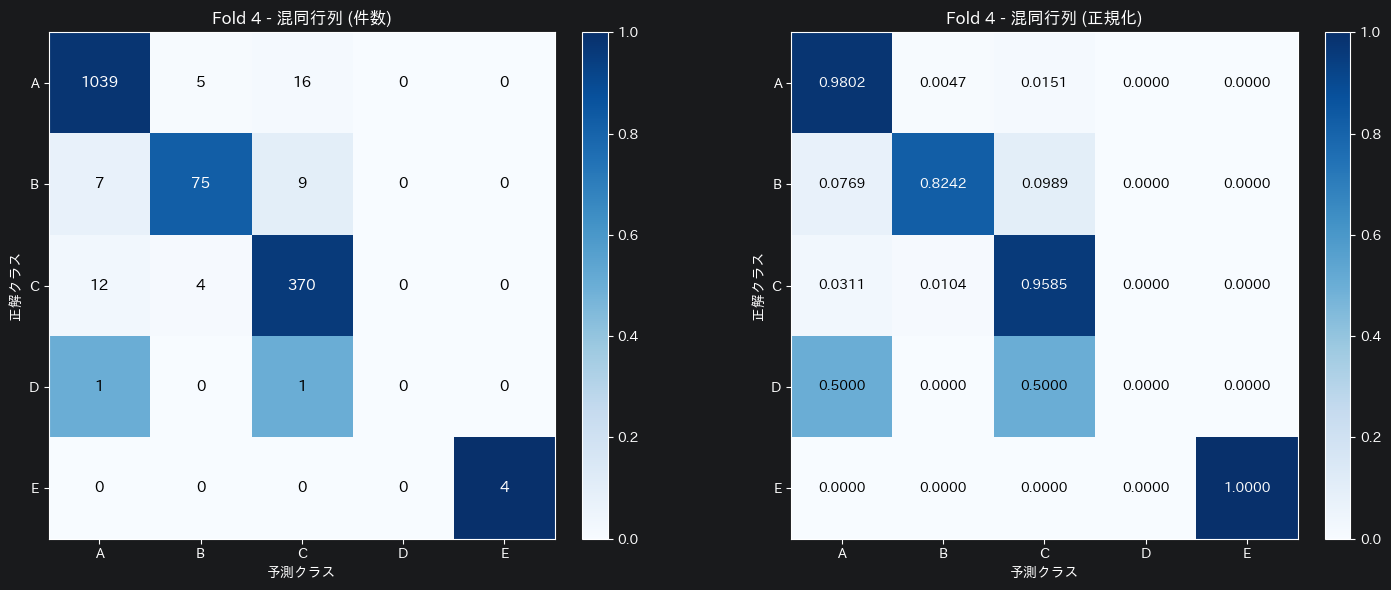


Fold 5/5 開始


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1189.76it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Eval Loss,Eval Accuracy,Eval Precision,Eval Recall,Eval F1 Macro,Accuracy,Precision,Recall,F1 Macro
1,0.368221,0.183144,0.143435,0.967115,0.566344,0.562101,0.563724,0.955282,0.545037,0.544307,0.544019
2,0.142190,0.167639,0.098306,0.975701,0.582009,0.561963,0.570415,0.953986,0.556987,0.539549,0.545861
3,0.086810,0.190052,0.077169,0.980723,0.783795,0.737181,0.758764,0.951393,0.761440,0.625833,0.674698
4,0.052685,0.156379,0.030507,0.993358,0.721797,0.760966,0.737899,0.963707,0.669864,0.698597,0.678500
5,0.040163,0.147609,0.021486,0.994816,0.956771,0.781284,0.793016,0.968892,0.917069,0.808251,0.845779
6,0.026799,0.161442,0.017556,0.995464,0.956007,0.836884,0.878958,0.967596,0.857654,0.808895,0.829696
7,0.022211,0.159457,0.019080,0.994492,0.914739,0.817459,0.852703,0.962411,0.810491,0.812424,0.803802
8,0.023849,0.193991,0.014227,0.995788,0.964393,0.883426,0.912721,0.962411,0.826678,0.848172,0.833819
9,0.019286,0.172508,0.012461,0.995788,0.899372,0.937500,0.916287,0.963059,0.819605,0.847042,0.824250
10,0.018739,0.175596,0.017245,0.993034,0.951940,0.886416,0.907854,0.966299,0.786865,0.862741,0.818897


[Epoch 1] Train Loss:0.3682 | Train Acc:0.9671 | Val Loss:0.1831 | Val Acc:0.9553 | Val Precision:0.5450 | Val Recall:0.5443 | Val F1:0.5440
[Epoch 2] Train Loss:0.1422 | Train Acc:0.9757 | Val Loss:0.1676 | Val Acc:0.9540 | Val Precision:0.5570 | Val Recall:0.5395 | Val F1:0.5459
[Epoch 3] Train Loss:0.0868 | Train Acc:0.9807 | Val Loss:0.1901 | Val Acc:0.9514 | Val Precision:0.7614 | Val Recall:0.6258 | Val F1:0.6747
[Epoch 4] Train Loss:0.0527 | Train Acc:0.9934 | Val Loss:0.1564 | Val Acc:0.9637 | Val Precision:0.6699 | Val Recall:0.6986 | Val F1:0.6785
[Epoch 5] Train Loss:0.0402 | Train Acc:0.9948 | Val Loss:0.1476 | Val Acc:0.9689 | Val Precision:0.9171 | Val Recall:0.8083 | Val F1:0.8458
[Epoch 6] Train Loss:0.0268 | Train Acc:0.9955 | Val Loss:0.1614 | Val Acc:0.9676 | Val Precision:0.8577 | Val Recall:0.8089 | Val F1:0.8297
[Epoch 7] Train Loss:0.0222 | Train Acc:0.9945 | Val Loss:0.1595 | Val Acc:0.9624 | Val Precision:0.8105 | Val Recall:0.8124 | Val F1:0.8038
[Epoch 8] Tra

Training Loss,Validation Loss,Epoch,Eval Loss,Eval Accuracy,Eval Precision,Eval Recall,Eval F1 Macro
0.008056,No log,20,0.007900,0.996436,0.997871,0.866652,0.902533


[Epoch 20] Train Loss:0.0081 | Train Acc:0.9964 | Val Loss:0.2053 | Val Acc:0.9650 | Val Precision:0.8557 | Val Recall:0.8566 | Val F1:0.8561


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Macro
0.008056,0.205277,20,0.965003,0.855678,0.856601,0.856136



Fold 5 最終評価結果: {'eval_loss': 0.20527662336826324, 'eval_accuracy': 0.9650032404407, 'eval_precision': 0.855677836523612, 'eval_recall': 0.8566009911488454, 'eval_f1_macro': 0.8561361587808018}



Classification Report:
              precision    recall  f1-score   support

           A     0.9811    0.9783    0.9797      1060
           B     0.8462    0.8462    0.8462        91
           C     0.9512    0.9585    0.9548       386
           D     0.5000    0.5000    0.5000         2
           E     1.0000    1.0000    1.0000         4

    accuracy                         0.9650      1543
   macro avg     0.8557    0.8566    0.8561      1543
weighted avg     0.9651    0.9650    0.9650      1543



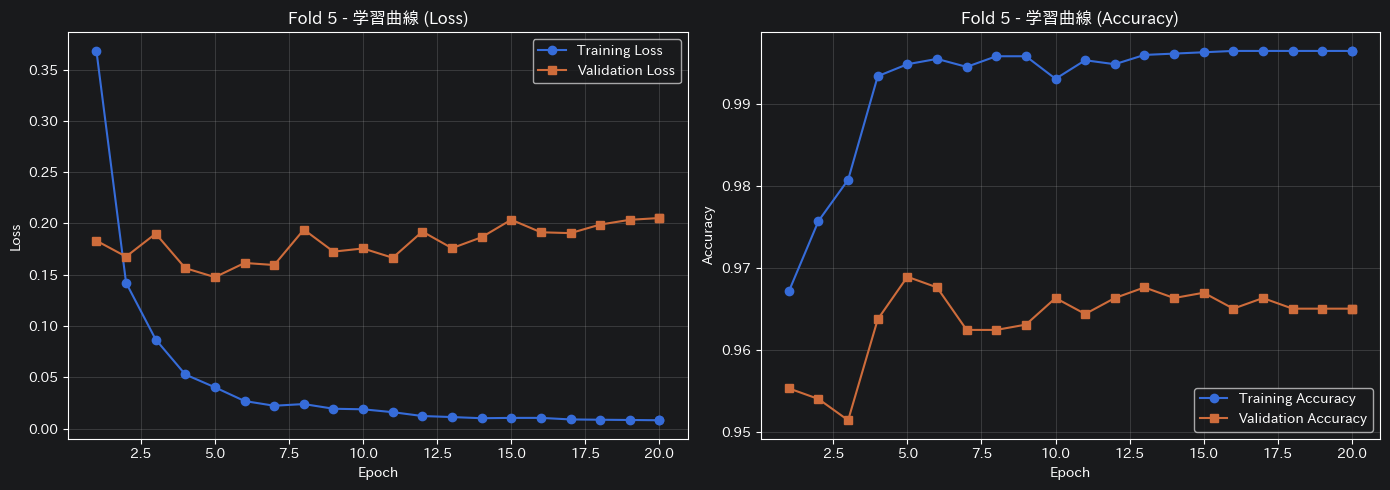

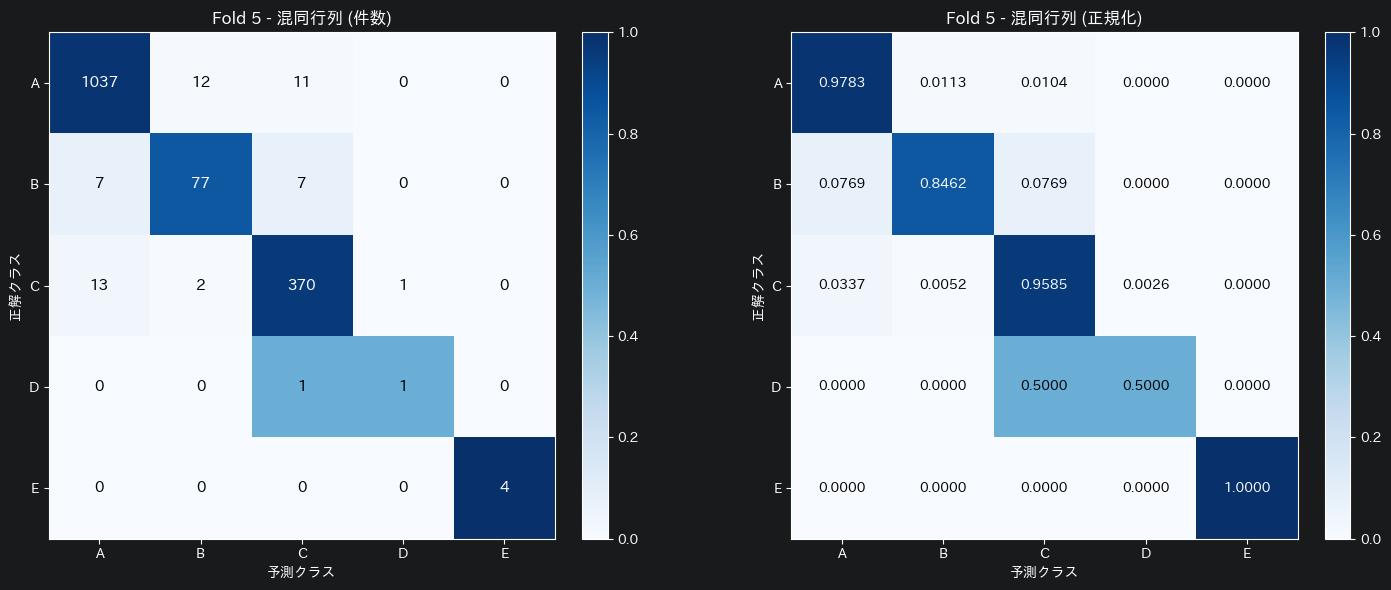

In [8]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_results = []     # 各foldのMacro F1などを保持
fold_histories = []   # 各foldの学習履歴
best_f1 = -1.0
best_fold = -1
best_model_state = None

X = df["id"].values
y = df["label_id"].values

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n{'='*70}")
    print(f"Fold {fold}/{N_SPLITS} 開始")
    print(f"{'='*70}")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    train_dataset = GPCRImageDataset(train_df, IMAGE_DIR, processor)
    val_dataset = GPCRImageDataset(val_df, IMAGE_DIR, processor)

    # モデル初期化(各foldごとに再初期化)
    model = ViTForImageClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_CLASSES,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )

    training_args = TrainingArguments(
        output_dir=os.path.join(OUTPUT_DIR, f"fold_{fold}_checkpoint"),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        fp16=True,
        report_to="none",
        seed=SEED,
        dataloader_num_workers=0,  # Windows では 0 にする
        remove_unused_columns=False,
        load_best_model_at_end=False,
    )

    history_cb = HistoryCallback(train_dataset=train_dataset)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[history_cb],
    )

    # コールバックにtrainer参照を後から渡す(循環参照回避)
    history_cb.set_trainer(trainer)

    trainer.train()

    # 最終評価
    eval_result = trainer.evaluate()
    print(f"\nFold {fold} 最終評価結果: {eval_result}")

    # 予測 → 混同行列・classification_report
    pred_output = trainer.predict(val_dataset)
    y_pred = np.argmax(pred_output.predictions, axis=-1)
    y_true = pred_output.label_ids

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

    # 学習曲線・混同行列描画
    plot_learning_curve(history_cb.history, fold)
    plot_confusion_matrix(cm, fold)

    macro_f1 = eval_result["eval_f1_macro"]
    fold_results.append({
        "fold": fold,
        "accuracy": eval_result["eval_accuracy"],
        "precision": eval_result["eval_precision"],
        "recall": eval_result["eval_recall"],
        "f1_macro": macro_f1,
    })
    fold_histories.append(history_cb.history)

    # ベストモデル更新
    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_fold = fold
        best_model_state = {k: v.cpu().clone() for k, v in trainer.model.state_dict().items()}
        best_model_ref = trainer.model

    # メモリ解放
    del trainer, model
    torch.cuda.empty_cache()

## 9. 交差検証の結果

In [9]:
result_df = pd.DataFrame(fold_results)
print("各Foldの結果:")
print(result_df.to_string(index=False))

print("\n平均値:")
print(result_df.drop(columns=["fold"]).mean())
print("\n標準偏差:")
print(result_df.drop(columns=["fold"]).std())

print(f"\nBest Fold: {best_fold} (Macro F1 = {best_f1:.4f})")

各Foldの結果:
 fold  accuracy  precision   recall  f1_macro
    1  0.974093   0.741245 0.762956  0.749368
    2  0.961763   0.820563 0.802828  0.801698
    3  0.966948   0.774472 0.701803  0.731373
    4  0.964355   0.761663 0.752583  0.756817
    5  0.965003   0.855678 0.856601  0.856136

平均値:
accuracy     0.966432
precision    0.790724
recall       0.775354
f1_macro     0.779078
dtype: float64

標準偏差:
accuracy     0.004667
precision    0.046546
recall       0.057961
f1_macro     0.050258
dtype: float64

Best Fold: 5 (Macro F1 = 0.8561)


## 10. Best Model を `.safetensor` 形式で保存

In [10]:
from safetensors.torch import save_file

# ベストモデル復元
best_model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
best_model.load_state_dict(best_model_state)

# safetensors形式での保存
save_path = os.path.join(OUTPUT_DIR, "model.safetensors")
# contiguousに変換しておく
state_dict_contig = {k: v.contiguous() for k, v in best_model.state_dict().items()}
save_file(state_dict_contig, save_path)

# 設定ファイル/processorも一緒に保存しておく
best_model.config.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)

# Best foldの情報を記録
with open(os.path.join(OUTPUT_DIR, "best_fold_info.txt"), "w") as f:
    f.write(f"Best Fold: {best_fold}\n")
    f.write(f"Best Macro F1: {best_f1:.4f}\n")
    f.write(f"\n各Foldの結果:\n{result_df.to_string(index=False)}\n")

print(f"ベストモデル(Fold {best_fold}, Macro F1 = {best_f1:.4f})を保存しました:")
print(f"  → {save_path}")

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 455.66it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ベストモデル(Fold 5, Macro F1 = 0.8561)を保存しました:
  → ../models/vit-bias-profs\model.safetensors
